In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Section 3: Model Training (MLP)

### What You Will Do

* Scale input features
* Train a neural network model
* Monitor training performance
* Evaluate and interpret results

### Key Idea

MLP is a neural network that learns patterns through layers of interconnected neurons.

Feature scaling and model parameters (e.g., learning rate, hidden layers) affect performance.

Proper training and validation are important.


####<font color="#FF69B4">PROMPT: "Please set the working directory to /content/drive/MyDrive/WORKSHOP-Intro-ML-Predict-DO"

In [ ]:
import os

working_directory = '/content/drive/MyDrive/WORKSHOP-Intro-ML-Predict-DO'
os.chdir(working_directory)
print(f"Working directory set to: {os.getcwd()}")

Working directory set to: /content/drive/MyDrive/WORKSHOP-Intro-ML-Predict-DO


####<font color="#FF69B4">PROMPT: "Please load the "CBP_CleanedData/Final_Upper_StationCB3.2.csv" as df "

In [ ]:
import pandas as pd

file_path = 'CBP_CleanedData/Final_Upper_StationCB3.2.csv'
df= pd.read_csv(file_path)

print(f"DataFrame loaded from: {file_path}")
print(f"Shape of df: {df.shape}")
print("First 5 rows of df:")
print(df.head())

DataFrame loaded from: CBP_CleanedData/Final_Upper_StationCB3.2.csv
Shape of df: (617, 8)
First 5 rows of df:
  MonitoringStation  SampleDate  CHLA  SALINITY       TN     TP  WTEMP   DO
0             CB3.2  1984-07-12   2.7      1.01  1.39600  0.063   24.5  4.4
1             CB3.2  1984-07-25   5.3      0.79  1.53375  0.070   26.0  1.3
2             CB3.2  1984-08-07  17.4      3.06  1.21200  0.044   26.2  0.0
3             CB3.2  1984-08-30   6.0      6.87  1.03900  0.041   25.3  2.6
4             CB3.2  1984-09-12   7.3      7.87  0.57350  0.031   23.1  2.7


####<font color="#FF69B4">PROMPT:"Please use df, set CHLA, SALINITY, TN, TP, and WTEMP as the feature variabes X, set DO as the target variable y"

In [ ]:
feature_columns = ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
target_column = 'DO'

X = df[feature_columns]
y = df[target_column]

print(f"Feature variables (X): {feature_columns}")
print(f"Target variable (y): {target_column}")
print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Feature variables (X): ['CHLA', 'SALINITY', 'TN', 'TP', 'WTEMP']
Target variable (y): DO
Shape of features (X): (617, 5)
Shape of target (y): (617,)


####<font color="#FF69B4">PROMPT: "Please split the X and y into training and testing sets using an 80/20 ratio, name it X_train, y_train, X_test, y_test"

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (493, 5)
X_test shape: (124, 5)
y_train shape: (493,)
y_test shape: (124,)


####<font color="#FF69B4">PROMPT: "Please scale the input features using StandardScaler to normalize both the training and test data."

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

Features scaled successfully!
Shape of X_train_scaled: (493, 5)
Shape of X_test_scaled: (124, 5)


###<font color="#FF69B4">PROMPT: "Please use TensorFlow to train a 2-layer MLP model using the training data. Use 64 neurons in the first layer and 32 neurons in the second layer. Please train the model for 100 epochs with a batch size of 32, use a validation split of 0.2, and apply early stopping. Please name the model mlp_model. Please plot the MSE loss for both training and validation over epochs to assess the learning process. There is no need to predict on the test data at this stage."

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MLP model trained successfully!


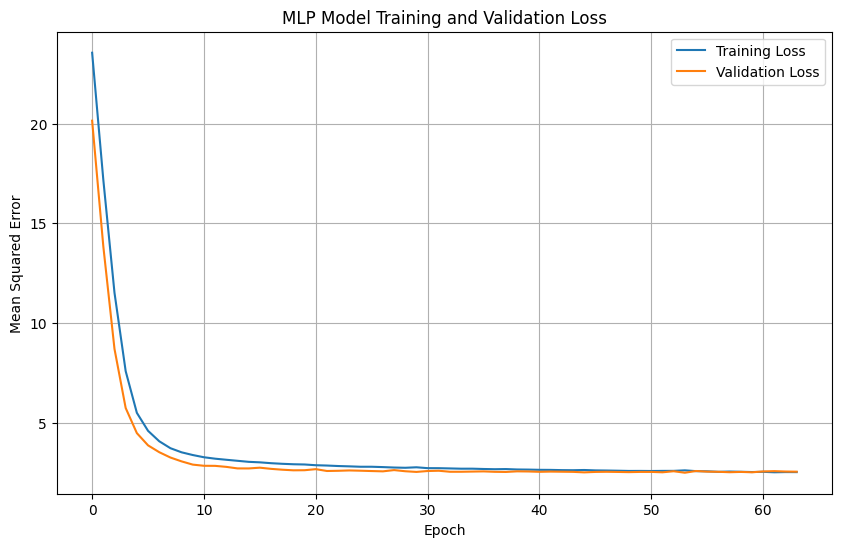

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define the MLP model
mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression
])

# Compile the model
mlp_model.compile(optimizer='adam', loss='mean_squared_error')

# Define Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = mlp_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

print("MLP model trained successfully!")

# Plotting the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MLP Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

###<font color="#FF69B4">PROMPT: "Evaluate the MLP_model performance on the test set using RMSE and R², plot predicted and true DO values to visually assess model performance."

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
MLP Model Performance on Test Set:
RMSE: 1.5513
R-squared: 0.7644


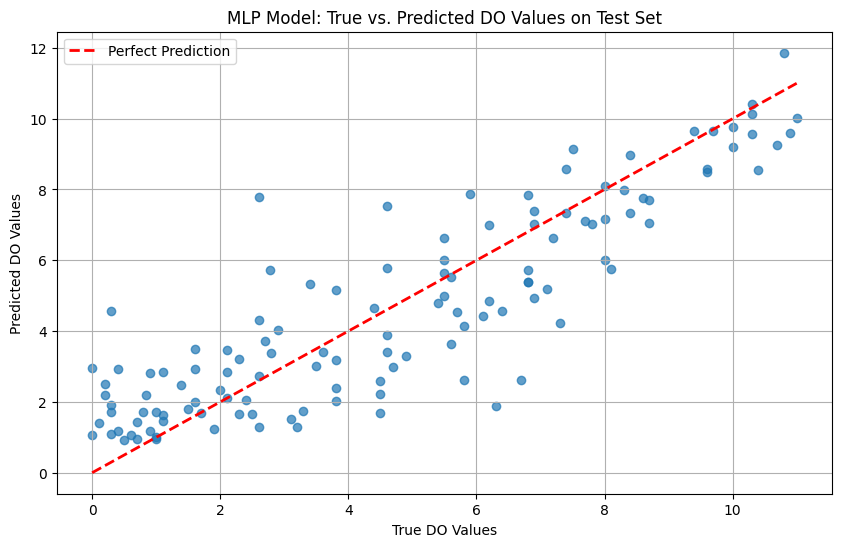

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = mlp_model.predict(X_test_scaled).flatten()

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

print(f"MLP Model Performance on Test Set:")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

# Plot predicted vs. true DO values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True DO Values')
plt.ylabel('Predicted DO Values')
plt.title('MLP Model: True vs. Predicted DO Values on Test Set')
plt.legend()
plt.grid(True)
plt.show()

###<font color="#FF69B4">PROMPT: "Please use SHAP (SHapley Additive exPlanations) to interpret how each feature contributes to the mlp_model predictions, and visualize with summary_plot"

Calculating SHAP values... This may take a moment.
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


ExactExplainer explainer:   1%|          | 1/124 [00:00<?, ?it/s]

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer:   2%|▏         | 3/124 [00:10<00:23,  5.16it/s]

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


...

ExactExplainer explainer:  99%|█████████▉| 123/124 [01:10<00:00,  1.39it/s]

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer: 100%|██████████| 124/124 [01:10<00:00,  1.61it/s]

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


ExactExplainer explainer: 125it [01:10,  1.75it/s]


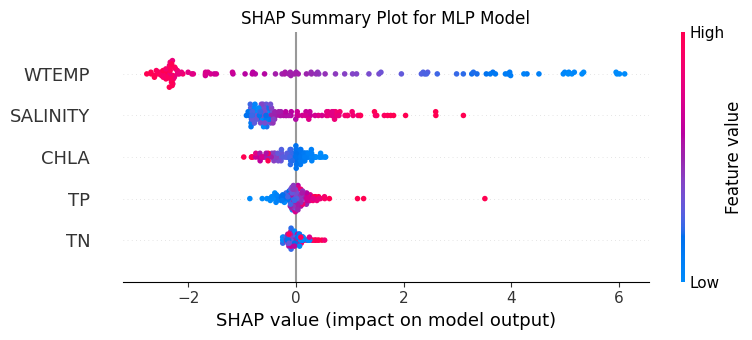

SHAP summary plot generated successfully.


In [ ]:
import shap
import numpy as np

# Assuming mlp_model, X_train_scaled, X_test_scaled, and feature_columns are already defined.

# Create a SHAP explainer
# For Keras models, we need to wrap the predict method
explainer = shap.Explainer(mlp_model.predict, X_train_scaled)

# Calculate SHAP values for the test set
# This might take a while depending on the size of X_test_scaled
print("Calculating SHAP values... This may take a moment.")
shap_values = explainer(X_test_scaled)

# Ensure shap_values is a 2D array if the model output is 1D for regression
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# Visualize the SHAP values using a summary plot
# We pass the original X_test DataFrame for feature names
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_columns, show=False)
plt.title('SHAP Summary Plot for MLP Model')
plt.tight_layout()
plt.show()

print("SHAP summary plot generated successfully.")

###<font color="#FF69B4">Prompt: "Please plot the average absolute contribution of each feature to the model predictions"

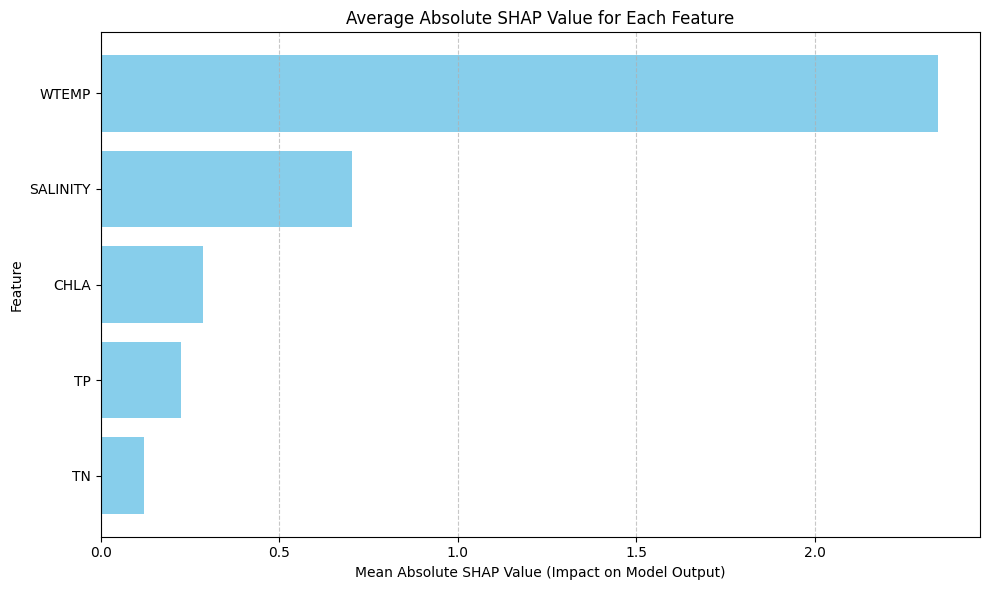

Average Absolute Contribution of Each Feature to MLP Model Predictions:
 Feature  Mean Absolute SHAP Value
   WTEMP                  2.345832
SALINITY                  0.703137
    CHLA                  0.285344
      TP                  0.225309
      TN                  0.121619


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure shap_values_array is correctly assigned
# It seems `shap_values` is already a numpy array from the previous cell's output (KTx6-xyfQlfp)
# If it were a list, we'd need to take the first element as done before.

# Safely get shap_values_array, accounting for potential list output from explainer
if isinstance(shap_values, list):
    shap_values_array = shap_values[0]
else:
    # If shap_values is a shap.Explanation object, get its values attribute
    shap_values_array = shap_values.values if hasattr(shap_values, 'values') else shap_values

# Calculate the mean absolute SHAP value for each feature
mean_abs_shap_values = np.mean(np.abs(shap_values_array), axis=0)

# Create a DataFrame for better visualization
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Mean Absolute SHAP Value': mean_abs_shap_values
})

# Sort by importance for better plot readability
feature_importance = feature_importance.sort_values(by='Mean Absolute SHAP Value', ascending=False)

# Plotting the average absolute contribution
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Mean Absolute SHAP Value'], color='skyblue')
plt.xlabel('Mean Absolute SHAP Value (Impact on Model Output)')
plt.ylabel('Feature')
plt.title('Average Absolute SHAP Value for Each Feature')
plt.gca().invert_yaxis() # To have the most important feature at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Average Absolute Contribution of Each Feature to MLP Model Predictions:")
print(feature_importance.to_string(index=False))

####<font color="#FF69B4">PROMPT:"Please visualize how each input feature influences its SHAP value using seaborn regression plots.Please add a LOWESS trend line to each plot."

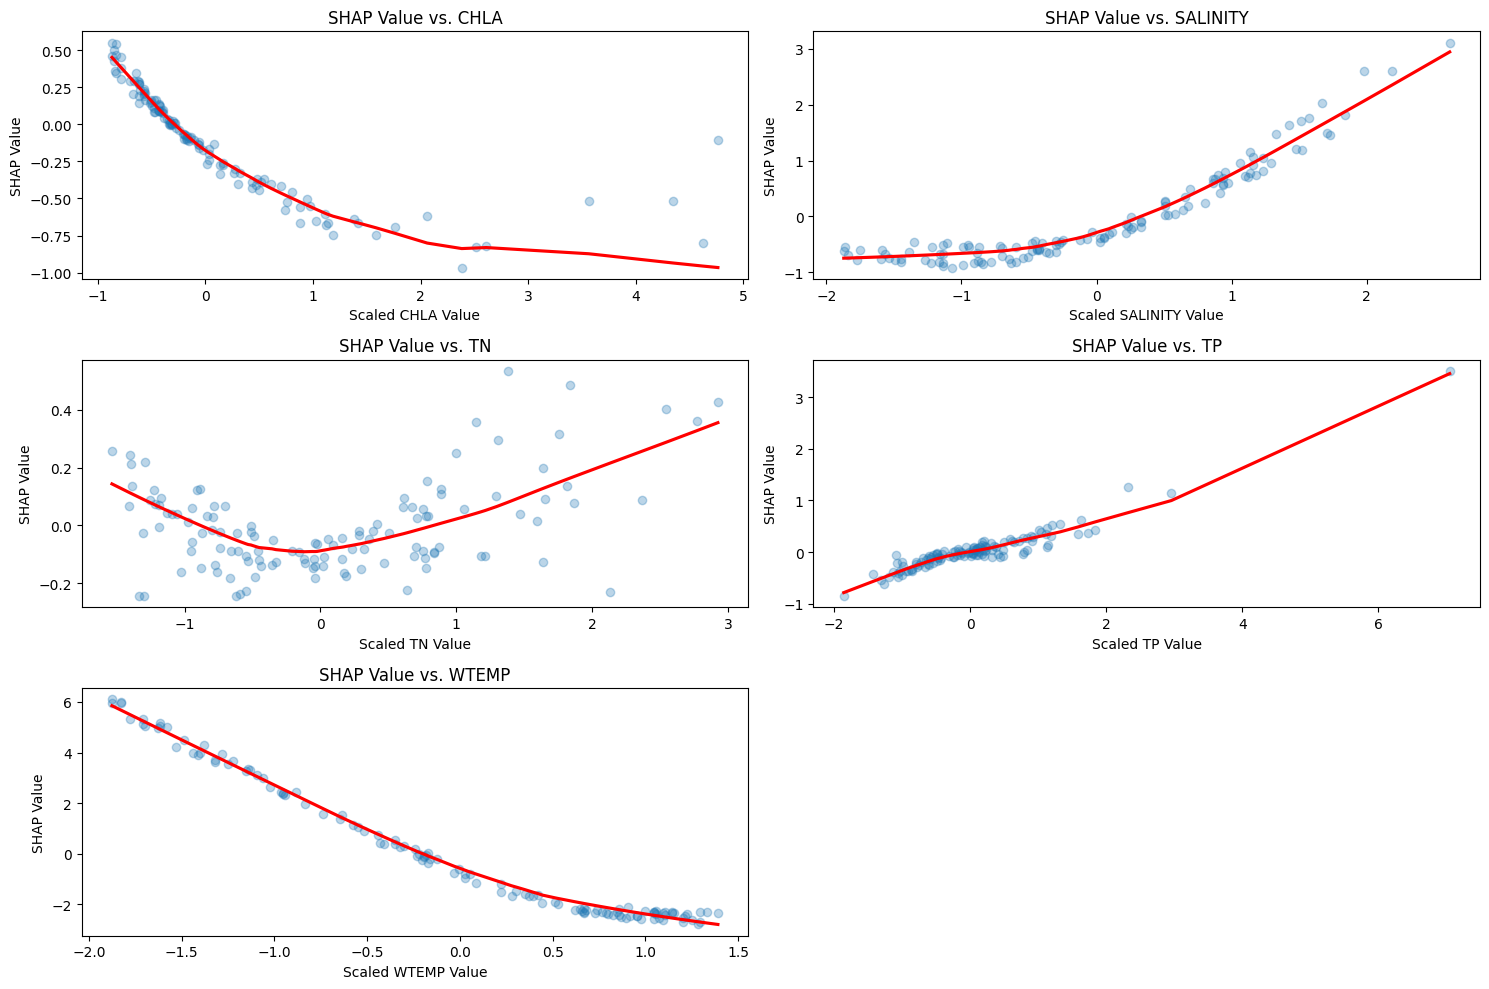

Individual feature influence plots generated successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure shap_values_array is correctly assigned as a numpy array
if isinstance(shap_values, list):
    shap_values_array = shap_values[0]
else:
    shap_values_array = shap_values.values if hasattr(shap_values, 'values') else shap_values

# Assuming X_test_scaled is a numpy array and feature_columns is a list of feature names

plt.figure(figsize=(15, 10))
num_features = len(feature_columns)
rows = int(np.ceil(num_features / 2))
cols = 2

for i, feature_name in enumerate(feature_columns):
    plt.subplot(rows, cols, i + 1)
    sns.regplot(x=X_test_scaled[:, i], y=shap_values_array[:, i], lowess=True, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'SHAP Value vs. {feature_name}')
    plt.xlabel(f'Scaled {feature_name} Value')
    plt.ylabel('SHAP Value')

plt.tight_layout()
plt.show()

print("Individual feature influence plots generated successfully.")

###<font color="#FF69B4">PROMPT: "Please create the folder SavedModels/MLP/Run_1"

In [ ]:
import os

folder_path = 'SavedModels/MLP/Run_1'
os.makedirs(folder_path, exist_ok=True)
print(f"Folder '{folder_path}' created successfully!")

Folder 'SavedModels/MLP/Run_1' created successfully!


###<font color="#FF69B4">PROMPT: "Please save the trained MLP model in the Run_1 folder as mlp_model.h5. Please include the training data used, target and feature list, and other metadata of the model."

In [ ]:
import os
import json
import tensorflow as tf
import numpy as np # Import numpy for float conversion

# Define the path to save the model and metadata
model_save_path = os.path.join(folder_path, 'mlp_model.h5')

# Save the Keras MLP model
mlp_model.save(model_save_path)
print(f"MLP model saved successfully to: {model_save_path}")

# Prepare model metadata
metadata = {
    'model_name': 'MLP Regression Model',
    'feature_columns': feature_columns,
    'target_column': target_column,
    'training_data_info': {
        'X_train_shape': list(X_train.shape),
        'y_train_shape': list(y_train.shape)
    },
    'test_data_info': {
        'X_test_shape': list(X_test.shape),
        'y_test_shape': list(y_test.shape)
    },
    'model_evaluation_metrics': {
        'test_rmse': float(rmse), # Convert numpy float to standard float
        'test_r2': float(r2)     # Convert numpy float to standard float
    },
    'preprocessing': {
        'scaling': 'StandardScaler'
    },
    'model_architecture_summary': [], # Will populate with summary
    'notes': 'Trained with 2-layer MLP (64-32 neurons), 100 epochs, batch size 32, validation split 0.2, early stopping.'
}

# Get model architecture summary and add it to metadata
# Redirect print output to a string to capture summary
import io
from contextlib import redirect_stdout
f = io.StringIO()
with redirect_stdout(f):
    mlp_model.summary()
s = f.getvalue()
metadata['model_architecture_summary'] = s.splitlines()

# Save metadata to a JSON file
metadata_save_path = os.path.join(folder_path, 'mlp_model_metadata.json')
with open(metadata_save_path, 'w') as f_json:
    json.dump(metadata, f_json, indent=4)
print(f"Model metadata saved successfully to: {metadata_save_path}")

print("Contents of the saved metadata file:")
print(json.dumps(metadata, indent=4))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,493 (29.27 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,996 (19.52 KB)

MLP model saved successfully to: SavedModels/MLP/Run_1/mlp_model.h5
Model metadata saved successfully to: SavedModels/MLP/Run_1/mlp_model_metadata.json
Contents of the saved metadata file:
{
    "model_name": "MLP Regression Model",
    "feature_columns": [
        "CHLA",
        "SALINITY",
        "TN",
        "TP",
        "WTEMP"
    ],
    "target_column": "DO",
    "training_data_info": {
        "X_train_shape": [
            493,
            5
        ],
        "y_train_shape": [
            493
        ]
    },
    "test_data_info": {
        "X_test_shape": [
            124,
            5
        ],
        "y_test_shape": [
            124
        ]
    },
    "model_evaluation_metrics": {
        "test_rmse": 1.540559979865392,
        "test_r2": 0.7677028024964989
    },
    "preprocessing": {
        "scaling": "StandardScaler"
    },
    "model_architecture_summary": [],
    "notes": "Trained with 2-layer MLP (64-32 neurons), 100 epochs, batch size 32, validation spl

### <font color="#F67">**Congratulations! You’ve also trained a Multiple Layer Perceptron(MLP) model on real Chesapeake Bay water quality data to predict bottom dissolved oxygen (DO). Now, let’s move on to prediction with your trained model!**